In [1]:
using Plots

In [2]:
using DataFrames, GLM

### 1. An Example of Linear Regression

To get started, we take the first example from the GLM documentation.  GLM is the abbreviation for Generalized Linear Model.

In [3]:
data = DataFrame(X=[1,2,3], Y=[2,4,7])

Row,X,Y
,Int64,Int64
1,1,2
2,2,4
3,3,7


In [4]:
ols = lm(@formula(Y ~ X), data)

StatsModels.TableRegressionModel{LinearModel{GLM.LmResp{Vector{Float64}}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

Y ~ 1 + X

Coefficients:
─────────────────────────────────────────────────────────────────────────
                 Coef.  Std. Error      t  Pr(>|t|)  Lower 95%  Upper 95%
─────────────────────────────────────────────────────────────────────────
(Intercept)  -0.666667    0.62361   -1.07    0.4788   -8.59038    7.25704
X             2.5         0.288675   8.66    0.0732   -1.16797    6.16797
─────────────────────────────────────────────────────────────────────────

In [5]:
stderror(ols)

2-element Vector{Float64}:
 0.6236095644623237
 0.2886751345948129

In [6]:
predict(ols)

3-element Vector{Float64}:
 1.8333333333333304
 4.333333333333333
 6.833333333333336

In [7]:
line(x) = -2/3 + 2.5*x

line (generic function with 1 method)

In [8]:
[line(t) for t in [1,2,3]]

3-element Vector{Float64}:
 1.8333333333333335
 4.333333333333333
 6.833333333333333

### 2. Fitting Average Temperatures

In Lecture 5, we looked at the average temperatures in Chicago over the last 100 years.

In [9]:
using DelimitedFiles

In [10]:
A = readdlm("tempChicago100years.txt")

101×14 Matrix{Any}:
     "Year"    "Jan"    "Feb"    "Mar"  …    "Nov"    "Dec"    "Annual"
 1922        24.8     29.4     39.3        44.6     29.9     52.1
 1923        30.7     22.3     33.0        43.8     39.7     50.3
 1924        19.7     28.8     34.6        41.5     23.3     48.1
 1925        25.9     32.2     39.7        38.9     25.3     50.3
 1926        27.3     30.9     30.2     …  37.1     26.5     48.0
 1927        24.8     34.9     42.0        43.2     26.9     50.6
 1928        25.2     30.3     36.9        42.2     32.1     49.6
 1929        17.6     21.6     43.3        36.3     28.6     48.5
 1930        20.1     37.1     36.1        42.4     29.7     51.0
 1931        32.0     35.6     34.9     …  50.0     38.4     53.9
 1932        33.6     34.9     30.1        37.2     28.7     50.5
 1933        36.7     26.2     35.5        38.0     31.3     51.7
    ⋮                                   ⋱                    
 2010        21.9     26.7     41.7        41.5     22

In [11]:
dectemp = A[2:end,13]

100-element Vector{Any}:
 29.9
 39.7
 23.3
 25.3
 26.5
 26.9
 32.1
 28.6
 29.7
 38.4
 28.7
 31.3
 26.2
  ⋮
 22.5
 35.2
 36.1
 23.3
 32.0
 39.0
 25.0
 27.2
 33.2
 34.0
 32.8
 38.0

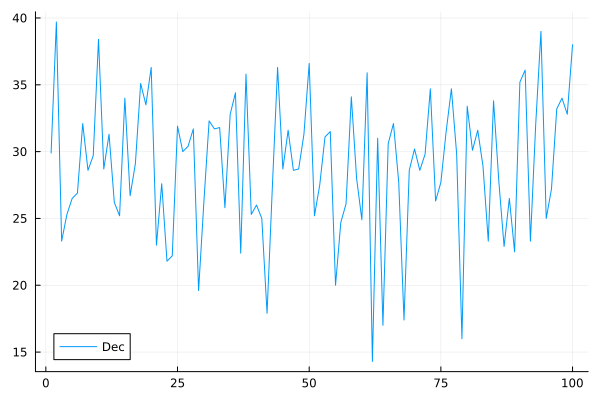

In [12]:
plot(1:100, dectemp, label="Dec", legend=:bottomleft)

In [13]:
# savefig("decemberTemperatures.png")

In [14]:
years = A[2:end,1]

100-element Vector{Any}:
 1922
 1923
 1924
 1925
 1926
 1927
 1928
 1929
 1930
 1931
 1932
 1933
 1934
    ⋮
 2010
 2011
 2012
 2013
 2014
 2015
 2016
 2017
 2018
 2019
 2020
 2021

In [15]:
tempdf = DataFrame(X=Vector{Float64}(years),Y=Vector{Float64}(dectemp))

Row,X,Y
,Float64,Float64
1,1922.0,29.9
2,1923.0,39.7
3,1924.0,23.3
4,1925.0,25.3
5,1926.0,26.5
6,1927.0,26.9
7,1928.0,32.1
8,1929.0,28.6
9,1930.0,29.7


In [16]:
olstemp = lm(@formula(Y ~ X), tempdf)

StatsModels.TableRegressionModel{LinearModel{GLM.LmResp{Vector{Float64}}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

Y ~ 1 + X

Coefficients:
─────────────────────────────────────────────────────────────────────────────
                   Coef.  Std. Error     t  Pr(>|t|)    Lower 95%   Upper 95%
─────────────────────────────────────────────────────────────────────────────
(Intercept)  20.4113      35.8233     0.57    0.5701  -50.6789     91.5016
X             0.00433003   0.0181687  0.24    0.8121   -0.0317251   0.0403851
─────────────────────────────────────────────────────────────────────────────

In [17]:
cff = coef(olstemp)

2-element Vector{Float64}:
 20.41133993398407
  0.0043300330033050624

In [18]:
predicted = [cff[1] + cff[2]*t for t in 1922:2021]

100-element Vector{Float64}:
 28.7336633663364
 28.737993399339707
 28.74232343234301
 28.746653465346316
 28.75098349834962
 28.755313531352925
 28.75964356435623
 28.763973597359538
 28.76830363036284
 28.772633663366147
 28.77696369636945
 28.781293729372756
 28.785623762376062
  ⋮
 29.114706270627245
 29.11903630363055
 29.123366336633858
 29.12769636963716
 29.132026402640467
 29.13635643564377
 29.140686468647075
 29.14501650165038
 29.149346534653688
 29.15367656765699
 29.158006600660297
 29.1623366336636

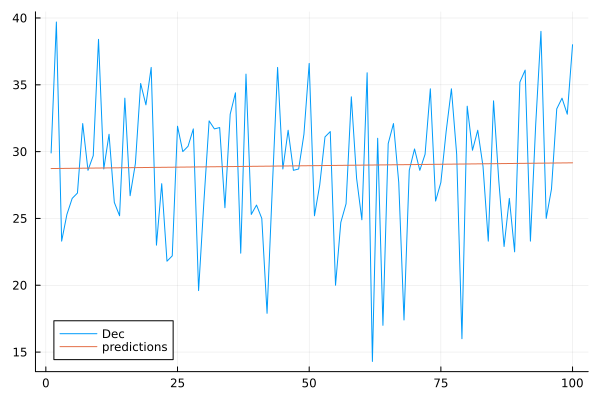

In [19]:
plot!(1:100, predicted, label="predictions")

In [20]:
# savefig("decemberTemperaturesFitted100.png")

In [21]:
Xlast20=Vector{Float64}(years[end-19:end])
Ylast20=Vector{Float64}(dectemp[end-19:end])
tempdf20 = DataFrame(X=Xlast20,Y=Ylast20)

Row,X,Y
,Float64,Float64
1,2002.0,30.1
2,2003.0,31.6
3,2004.0,28.9
4,2005.0,23.3
5,2006.0,33.8
6,2007.0,27.8
7,2008.0,22.9
8,2009.0,26.5
9,2010.0,22.5


In [22]:
olstemp20 = lm(@formula(Y ~ X), tempdf20)

StatsModels.TableRegressionModel{LinearModel{GLM.LmResp{Vector{Float64}}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

Y ~ 1 + X

Coefficients:
────────────────────────────────────────────────────────────────────────────────
                   Coef.  Std. Error      t  Pr(>|t|)      Lower 95%   Upper 95%
────────────────────────────────────────────────────────────────────────────────
(Intercept)  -607.168     387.689     -1.57    0.1347  -1421.67       207.337
X               0.316842    0.192736   1.64    0.1175     -0.0880802    0.721764
────────────────────────────────────────────────────────────────────────────────

In [23]:
cff20 = coef(olstemp20)

2-element Vector{Float64}:
 -607.1678947230805
    0.31684210525631645

In [24]:
predicted20 = [cff20[1] + cff20[2]*t for t in 2002:2021]

20-element Vector{Float64}:
 27.150000000065006
 27.466842105321348
 27.78368421057769
 28.10052631583403
 28.41736842109026
 28.7342105263466
 29.051052631602943
 29.367894736859284
 29.684736842115512
 30.001578947371854
 30.318421052628196
 30.635263157884538
 30.95210526314088
 31.268947368397107
 31.58578947365345
 31.90263157890979
 32.21947368416613
 32.53631578942236
 32.8531578946787
 33.169999999935044

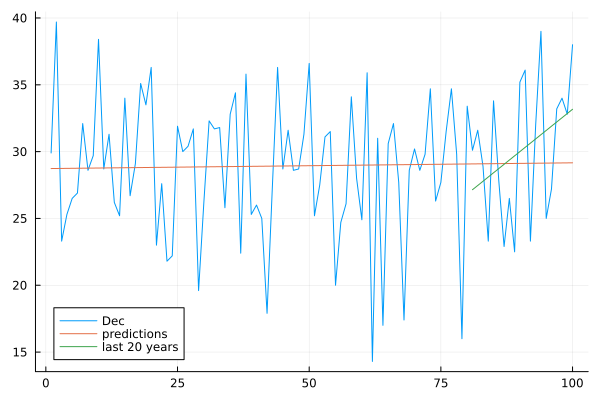

In [25]:
plot!(81:100, predicted20, label="last 20 years")

In [26]:
# savefig("decemberTemperaturesFittedLast20.png")